In [1]:
%matplotlib inline

import os, random, time, sys, warnings

import numpy as np
import scipy as sp
import pandas as pd
import torch
from src.utils import get_weight_masks, get_weight_masks_schaefer, get_file_str

# import plotting libraries
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 10})
plt.rcParams["svg.fonttype"] = "none"
plt.rc('font', family='DejaVu Sans')
import seaborn as sns
sns.set_style("white")
from src.plotting import my_reg_plot

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [2]:
# Device configuration
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')

In [3]:
save_figs = True

In [4]:
# directories
datadir = '/home/lindenmp/research_projects/neuro_rnn/data'
modeldir = '/media/lindenmp/storage_ssd/research_projects/neuro_rnn/results/pytorch/model'
outdir = '/home/lindenmp/research_projects/neuro_rnn/results/figs'

# data parameters
# task = 'PerceptualDecisionMaking-v0'
# task = 'MultiSensoryIntegration-v0'
task = 'ContextDecisionMaking-v0'
dt = 100
batch_size = 128
decision = 300
seq_len = 13
seq_len = seq_len + int((decision - 100) / dt)
seq_len = seq_len * 2
print(seq_len)

# RNN model and training parameters
rnn_model = 'rnn-tanh'
hidden_size = 100
n_runs = 25
n_epochs = 10000
lr = 0.001

# regularization parameters
reg_type = 'l2'
reg_weight = 0.001
mask_weights = True

if mask_weights and hidden_size == 50:
    n_io = '9-13'
if mask_weights and hidden_size == 100:
    n_io = '14-27'
if mask_weights and hidden_size == 200:
    n_io = '31-52'

30


In [5]:
timing = {'decision': decision}
env_kwargs = {'dt': dt, 'timing': timing}

config = {
    'datadir': datadir, 'outdir': outdir,
    'task': task, 'dt': dt, 'seq_len': seq_len, 'batch_size': batch_size,  # data parameters
    'rnn_model': rnn_model, 'hidden_size': hidden_size, 'n_runs': n_runs, 'n_epochs': n_epochs, 'lr': lr, 'mask_weights': mask_weights,  # RNN model and training parameters
    'reg_type': reg_type, 'reg_weight': reg_weight,  # regularization parameters
    'env_kwargs': env_kwargs,
    'n_io': n_io
}

# Model performance

In [6]:
color_palette = sns.color_palette("Set2")
kernel_types = ['sa_axis', 'euclidean', None]
kernel_labels = ['RNN-SA', 'RNN-E', 'RNN-Standard']

task-PerceptualDecisionMaking-v0-30-128-300_model-rnn-tanh-100-14-27-25-10000-0.001_wmask-True_reg-l2-0.001-sa_axis
task-PerceptualDecisionMaking-v0-30-128-300_model-rnn-tanh-100-14-27-25-10000-0.001_wmask-True_reg-l2-0.001-euclidean
task-PerceptualDecisionMaking-v0-30-128-300_model-rnn-tanh-100-14-27-25-10000-0.001_wmask-True_reg-l2-0.001-None
task-MultiSensoryIntegration-v0-30-128-300_model-rnn-tanh-100-14-27-25-10000-0.001_wmask-True_reg-l2-0.001-sa_axis
task-MultiSensoryIntegration-v0-30-128-300_model-rnn-tanh-100-14-27-25-10000-0.001_wmask-True_reg-l2-0.001-euclidean
task-MultiSensoryIntegration-v0-30-128-300_model-rnn-tanh-100-14-27-25-10000-0.001_wmask-True_reg-l2-0.001-None
task-ContextDecisionMaking-v0-30-128-300_model-rnn-tanh-100-14-27-25-10000-0.001_wmask-True_reg-l2-0.001-sa_axis
task-ContextDecisionMaking-v0-30-128-300_model-rnn-tanh-100-14-27-25-10000-0.001_wmask-True_reg-l2-0.001-euclidean
task-ContextDecisionMaking-v0-30-128-300_model-rnn-tanh-100-14-27-25-10000-0.001_

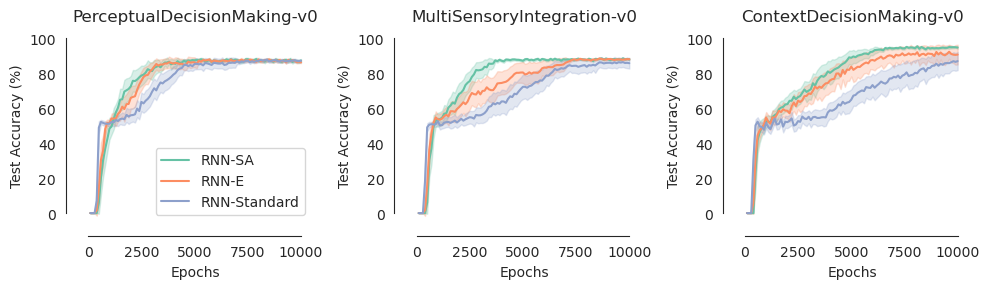

In [7]:
for hidden_size in [100,]:
    if mask_weights and hidden_size == 50:
        n_io = '9-13'
    if mask_weights and hidden_size == 100:
        n_io = '14-27'
    if mask_weights and hidden_size == 200:
        n_io = '31-52'
    config['hidden_size'] = hidden_size
    config['n_io'] = n_io
    for decision in [300,]:
        config['decision'] = decision
        timing = {'decision': decision}
        env_kwargs = {'dt': dt, 'timing': timing}
        config['env_kwargs'] = env_kwargs

        f, ax = plt.subplots(1, 3, figsize=(10, 3))
        n_logged_epochs = 100
        x_step = int(n_epochs / (n_logged_epochs))
        x = np.arange(x_step, n_epochs + x_step, x_step)

        for i, task in enumerate(['PerceptualDecisionMaking-v0', 'MultiSensoryIntegration-v0', 'ContextDecisionMaking-v0']):
            seq_len = 13
            seq_len = seq_len + int((decision - 100) / dt)
            seq_len = seq_len * 2

            config['task'] = task
            config['seq_len'] = seq_len

            for j, kernel_type in enumerate(kernel_types):
                config['kernel_type'] = kernel_type
                file_str = get_file_str(config)
                print(file_str)

                # load data
                log_args = np.load(os.path.join(modeldir, file_str + '.npy'), allow_pickle=True).item()
                test_accuracy = log_args['test_accuracy'][:, 1:] * 100

                # compute mean and ci
                accuracy_mean = test_accuracy.mean(axis=0)
                accuracy_std = test_accuracy.std(axis=0)
                ci = 1.96 * (accuracy_std / np.sqrt(n_runs))
                ci_lower = accuracy_mean - ci
                ci_upper = accuracy_mean + ci

                ax[i].plot(x, accuracy_mean, color=color_palette[j], label=str(kernel_labels[j]))
                ax[i].fill_between(x, ci_lower, ci_upper, color=color_palette[j], alpha=0.25)

            ax[i].set_xlabel('Epochs')
            ax[i].set_ylabel('Test Accuracy (%)')
            ax[i].set_ylim([-5, 105])
            if i == 0:
                ax[i].legend(loc='lower right')
            ax[i].set_title(task)

        sns.despine(offset=10, trim=True, left=False, right=True, top=True, bottom=False)

        # file_str = '-'.join(file_str.split('-')[:-1])
        # f.suptitle(file_str)
        f.tight_layout()
        plt.show()

        if save_figs:
            file_str = 'accuracy_h{0}_d{1}_r{2}'.format(hidden_size, decision, reg_weight)
            f.savefig(os.path.join(outdir, '{0}_{1}.png'.format(file_str, 'accuracy')), dpi=300, bbox_inches='tight', pad_inches=0.01)